# 11.3.2 网络随机与传播随机

## 学习目标与先修知识

在等接触预算下分层重复，按网络与传播两个层级描述随机变异。

先修：11.3.1 同步 SIR；11.1.2 重连随机基线；5.2 方差（variance）。

## 具体问题

同一个重连概率（probability）会生成不同网络；同一张网络上又会出现不同传播事件（event）。只在一张图上重复许多次，估不到结构实现之间的波动。该如何分层组织实验并公平比较两类连接结构？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先用 2 张网络、每张 2 次的人工结果手算：[[1,3],[5,7]] 的两张图均值为2和6。

In [2]:
print('图均值[2,6]；图内总体方差1；图均值之间总体方差4；总均值4。')

图均值[2,6]；图内总体方差1；图均值之间总体方差4；总均值4。


## 模型假设

比较两种重连概率 $p=0.05$ 与 $0.35$；均为12节点、初始规则度4、24条边，故每边传播概率与总边数口径相同，但度分布（degree distribution）仍可能变化。每组20个网络实现，每图30次动态重复；初始感染者按预定顺序轮换节点，不总是0号。两种结构的配对运行使用同一初始节点和同一组动态抽样表；网络种子与动态种子明确分层。人工有限实验不直接外推现实人群。

## 数学解释与推导

令 $Y_{gr}$ 为第 $g$ 张网络上第 $r$ 次传播的最终规模，$\bar Y_g=R^{-1}\sum_rY_{gr}$，总均值 $\bar Y=G^{-1}\sum_g\bar Y_g$。这里的图内总体方差 $V_{\mathrm{within}}=(GR)^{-1}\sum_{g,r}(Y_{gr}-\bar Y_g)^2$；图均值间方差 $V_{\mathrm{between}}=G^{-1}\sum_g(\bar Y_g-\bar Y)^2$。图内重复同时改变初始节点和传播抽样，因此图内方差不是纯传播噪声。两项分别描述这批结果在图内和图均值之间的散布。特别是每张图仅做有限次传播时，图均值间方差仍含传播均值的 Monte Carlo 抽样误差；估计纯网络间方差组分还需层次方差方法或更多动态重复。比较两方案差值时应在同一图索引与动态索引下配对，并同时报告失败/灭绝。作为不同模型（model）的参照，平均混合（homogeneous mixing）假设每人每步重新独立抽取 $d$ 个接触对象：若当前易感和感染比例为 $s_t,i_t$，则新感染比例为 $s_t[1-(1-\beta i_t)^d]$，恢复比例为 $\gamma i_t$。它与固定边网络的有限随机轨迹（trajectory）具有相同的名义接触次数，却不保留重复接触、聚类或早期灭绝；不能把其预测直接当作网络实验的真值。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def adjacency(n, edges):
    """Undirected simple graph; edges contain two distinct zero-based node indices."""
    a = [[0] * n for _ in range(n)]
    for i, j in edges:
        a[i][j] = a[j][i] = 1
    return a


def ring_rewire(n, k, probability, seed):
    """Teaching ring rewiring: fixed node/edge count, one endpoint retained."""
    import random
    rng = random.Random(seed)
    # Follow one ring direction; numeric order is only the undirected edge's storage form.
    original = [(i, (i + d) % n) for i in range(n)
                for d in range(1, k // 2 + 1)]
    edges = {tuple(sorted(edge)) for edge in original}
    for i, j in original:
        if rng.random() >= probability:
            continue
        options = [w for w in range(n) if w != i and tuple(sorted((i, w))) not in edges]
        if options:
            edges.remove(tuple(sorted((i, j))))
            edges.add(tuple(sorted((i, rng.choice(options)))))
    return sorted(edges)


def sir_fixed(n, edges, initial, beta, gamma, infection_draws, recovery_draws):
    """Synchronous S=0,I=1,R=2 updates with pre-specified uniform draws."""
    a = adjacency(n, edges)
    state = list(initial)
    history = [state.copy()]
    for edge_random, recovery_random in zip(infection_draws, recovery_draws):
        next_state = state.copy()
        for i in range(n):
            if state[i] == 0 and any(a[i][j] and state[j] == 1 and edge_random[i][j] < beta
                                     for j in range(n)):
                next_state[i] = 1
            elif state[i] == 1 and recovery_random[i] < gamma:
                next_state[i] = 2
        state = next_state
        history.append(state.copy())
    ever = sum(any(row[i] != 0 for row in history) for i in range(n))
    active_steps = sum(any(value == 1 for value in row) for row in history[:-1])
    return history, ever, active_steps


def nested_variation(replicates):
    """Each row is one network's dynamic repeats; population variances."""
    import numpy as np
    data = np.asarray(replicates, dtype=float)
    means = data.mean(axis=1)
    within = ((data - means[:, None]) ** 2).mean()
    between = ((means - means.mean()) ** 2).mean()
    return means.tolist(), float(within), float(between), float(data.mean())


def mean_mixing_sir(n, contacts, beta, gamma, steps):
    """Deterministic fractions under redrawn independent contacts each step."""
    susceptible, infectious, recovered = (n - 1) / n, 1 / n, 0.
    history = [[susceptible, infectious, recovered]]
    for _ in range(steps):
        new_cases = susceptible * (1 - (1 - beta * infectious) ** contacts)
        new_recovered = gamma * infectious
        susceptible -= new_cases
        infectious += new_cases - new_recovered
        recovered += new_recovered
        history.append([susceptible, infectious, recovered])
    return history

## 对照实验

构造两组同边数网络；20×30 层重复使用明确种子。右图保留逐图均值差与首次感染少于2人的比例，不只画平均轨迹。

p=0.05: 平均规模=11.000; 图内方差=7.205; 图均值间方差=0.185; 仅1人比例=0.047


p=0.35: 平均规模=11.002; 图内方差=7.630; 图均值间方差=0.121; 仅1人比例=0.055
平均混合参照的12步曾感染比例= 0.998 ；这是重新抽样接触的确定性近似，不是网络样本均值的解析解。


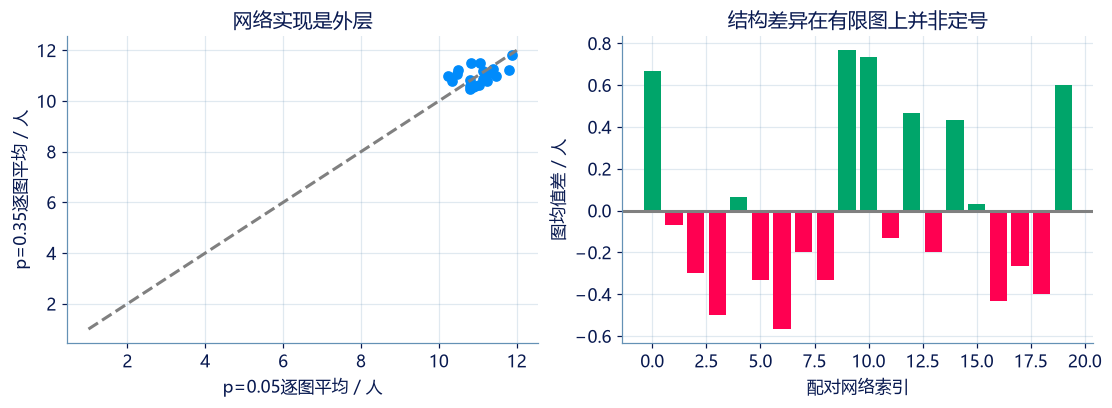

In [4]:
G,R=20,30; n=12; horizon=12; outputs={}
for p in [.05,.35]:
    table=[]
    for g in range(G):
        e=ring_rewire(n,4,p,1000+g)
        row=[]
        for r in range(R):
            rng=np.random.default_rng(900000+g*R+r)
            infection=rng.random((horizon,n,n)).tolist();recovery=rng.random((horizon,n)).tolist()
            start=(g+r)%n
            initial=[int(i==start) for i in range(n)]
            _,ever,_=sir_fixed(n,e,initial,.35,.22,infection,recovery)
            row.append(ever)
        table.append(row)
    outputs[p]=np.asarray(table)
    means,within,between,overall=nested_variation(table)
    print(f'p={p}: 平均规模={overall:.3f}; 图内方差={within:.3f}; 图均值间方差={between:.3f}; 仅1人比例={np.mean(outputs[p]==1):.3f}')
per_graph=outputs[.35].mean(axis=1)-outputs[.05].mean(axis=1)
mixing=np.array(mean_mixing_sir(n,4,.35,.22,horizon))
print('平均混合参照的12步曾感染比例=',round(1-mixing[-1,0],3),
      '；这是重新抽样接触的确定性近似，不是网络样本均值的解析解。')
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
axes[0].scatter(outputs[.05].mean(axis=1),outputs[.35].mean(axis=1),color=BLUE)
axes[0].plot([1,12],[1,12],'--',color='gray');axes[0].set(xlabel='p=0.05逐图平均 / 人',ylabel='p=0.35逐图平均 / 人',title='网络实现是外层')
axes[1].bar(range(G),per_graph,color=[GREEN if v>=0 else PINK for v in per_graph])
axes[1].axhline(0,color='gray');axes[1].set(xlabel='配对网络索引',ylabel='图均值差 / 人',title='结构差异在有限图上并非定号');plt.show()

## 结果解释

每张网络拥有30次传播，不把600次都误当成独立网络。即使总体均值不同，逐图差异可能方向不一致。平均混合参照每步重抽接触，固定网络则保留邻居关系；两者的末值差异反映了接触机制的变化。 从高度节点与边缘节点开始的结果可能不同：本节让起点跨节点轮换，两种结构中相同索引的实验仍保持同一起点和抽样表。

### 独立核对

人工小表复算两层方差；程序确认两组每张图节点与边数相同，并且两层随机种子（random seed）独立记录。

In [5]:
means,within,between,overall=nested_variation([[1,3],[5,7]])
np.testing.assert_allclose(means,[2,6]);np.testing.assert_allclose([within,between,overall],[1,4,4])
for p in [.05,.35]:
    assert outputs[p].shape==(20,30)
    assert all(len(ring_rewire(n,4,p,1000+g))==24 for g in range(G))
    assert outputs[p].min()>=1 and outputs[p].max()<=n
np.testing.assert_allclose(mixing.sum(axis=1),1.,atol=1e-12)
assert np.all((mixing>=0)&(mixing<=1))
print('分层方差、网络边数与传播规模边界一致。')

分层方差、网络边数与传播规模边界一致。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/11-03-%E6%8E%A5%E8%A7%A6%E7%BB%93%E6%9E%84%E4%B8%8E%E4%BC%A0%E6%92%AD/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：分开网络与传播重复

replicates[g][r] 是第 g 张网络上第 r 次传播的最终感染人数。每张图先求均值；网络内方差（variance）为所有观测（observation）减去本图均值后的平方平均，图均值间描述性方差为各图均值围绕总均值的平方平均，有限传播重复造成的均值抽样误差仍包含在内。返回各图均值、两种总体方差与总均值。

**函数与代码模板**

```python
def solve(
    replicates: list[list[float]],
) -> tuple[list[float], float, float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `replicates` | `list[list[float]]` | 至少2张图、每图至少2次，矩形表；各图重复次数相同。 | 人 |

**返回值**

按以下顺序返回元组：(network_means, within, between, overall)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `network_means` | `list[float]` | 逐图的传播均值。 | 人 |
| `within` | `float` | 图内总体方差。 | 人² |
| `between` | `float` | 图均值间的总体方差。 | 人² |
| `overall` | `float` | 全部观测均值。 | 人 |

**计算规则**

若 G 张图、R 次重复，within=∑_{g,r}(x_gr−mean_g)²/(GR)，between=∑_g(mean_g−overall)²/G。不是自由度（degrees of freedom）校正样本方差。

**约束与边界**

- 只计算题定有限图和数值模型（model）；返回普通 Python 列表、数值或元组。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| replicates | 至少2张图、每图至少2次，矩形表；各图重复次数相同。 | [[1.0, 3.0], [5.0, 7.0]] | 人 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
replicates = [[1.0, 3.0], [5.0, 7.0]]

result = solve(replicates)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| network_means | 逐图的传播均值。 | [2.0, 6.0] | 人 |
| within | 图内总体方差。 | 1 | 人² |
| between | 图均值间的总体方差。 | 4 | 人² |
| overall | 全部观测均值。 | 4 | 人 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([2.0, 6.0], 1.0, 4.0, 4.0)
```

**样例解释**

首例图均值为2和6，图内方差1，图均值间描述性方差4，总均值4。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：分开网络与传播重复](http://127.0.0.1:8000/chapters/11-03-%E6%8E%A5%E8%A7%A6%E7%BB%93%E6%9E%84%E4%B8%8E%E4%BC%A0%E6%92%AD/practice/?question=p11-nested-outbreak-variation)

### 第 2 题 · 单项选择题：一张网络重复很多次够吗

只生成一张重连图，在其上运行1000次传播。能够估计哪种随机性？

- **A.** 固定这张图条件下的传播随机性。
- **B.** 不同重连网络之间的结构变异。
- **C.** 所有真实人群的普遍效应。
- **D.** 网络生成概率（probability）的不确定性为零。

[作答：一张网络重复很多次够吗](http://127.0.0.1:8000/chapters/11-03-%E6%8E%A5%E8%A7%A6%E7%BB%93%E6%9E%84%E4%B8%8E%E4%BC%A0%E6%92%AD/practice/?question=p11-one-graph-many-draws)

### 第 3 题 · 单项选择题：定向干预的比较

比较随机删边与优先删高接触节点的边。什么设计更能支持结构差异？

- **A.** 两方案在同一原始网络上、相同删边预算，复用可比随机流并保留所有失败。
- **B.** 定向方案删两倍边后宣称更有效。
- **C.** 只报告最好一次结果。
- **D.** 把网络生成种子与传播种子混成一项且不记录。

[作答：定向干预的比较](http://127.0.0.1:8000/chapters/11-03-%E6%8E%A5%E8%A7%A6%E7%BB%93%E6%9E%84%E4%B8%8E%E4%BC%A0%E6%92%AD/practice/?question=p11-paired-intervention)

### 第 4 题 · 单项选择题：有限重复能支持什么

20 张网络、每张30次动态重复显示某方案的平均传播人数较低。哪项说法合理？

- **A.** 这已证明任何网络规模都如此。
- **B.** 应同时报告跨网络与网络内波动，并检查差值不确定性和预算。
- **C.** 只画一条代表性轨迹（trajectory）更可靠。
- **D.** 此结果直接等于真实人群因果效应。

[作答：有限重复能支持什么](http://127.0.0.1:8000/chapters/11-03-%E6%8E%A5%E8%A7%A6%E7%BB%93%E6%9E%84%E4%B8%8E%E4%BC%A0%E6%92%AD/practice/?question=p11-uncertainty-boundary)

**进一步阅读**

[NetworkX Watts–Strogatz 模型文档](https://networkx.org/documentation/stable/reference/generated/networkx.generators.random_graphs.watts_strogatz_graph.html)说明重连保留边数；本节的分层重复是额外的课程实验设计。